# CTR / Engagement Opportunity Scoring — FlyRank Search Intelligence Capstone

**Lane:** CTR / Engagement Opportunity Scoring
**Question:** Which visible pages (good average position, meaningful impressions) are under-capturing clicks relative to what their position would predict — and what should be done about each one?

**How to use this notebook**
1. Get a read token for the FlyRank ML Internship dataset on Hugging Face (gated, ~2 min approval).
2. Set it as an environment variable before launching Jupyter: `export HF_TOKEN=hf_xxx`
3. Run Starter Notebook 03 first (or skim it) to confirm the **exact table names and column names** in the warehouse release you were granted — the CONFIG cell below has my best-guess GSC-style schema (`page`, `query`, `impressions`, `clicks`, `position`, `date`). Adjust `CONFIG` to match reality before running the rest.
4. Run top to bottom. Every cell is written to fail loudly (assert / clear error) rather than silently produce nonsense if a column is missing.


In [1]:
from google.colab import userdata
import os

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

# verify - True aana chahiye
print(bool(os.environ.get('HF_TOKEN')))

True


In [2]:
import os
import duckdb
import numpy as np
import pandas as pd

# ---- CONFIG: adjust these to match the actual warehouse schema (check Starter Notebook 03) ----
CONFIG = {
    "hf_dataset_glob": "hf://datasets/flyrank/ml-internship-warehouse/**/*.parquet",  # PLACEHOLDER path — replace with the real hf:// path from the dataset card
    "page_col": "page",
    "query_col": "query",
    "impressions_col": "impressions",
    "clicks_col": "clicks",
    "position_col": "position",
    "date_col": "date",
}

HF_TOKEN = os.environ.get("HF_TOKEN")
assert HF_TOKEN, "Set HF_TOKEN in your environment before running this notebook."

In [3]:
#!pip install -U huggingface_hub -q

from huggingface_hub import HfApi
import os

api = HfApi(token=os.environ.get("HF_TOKEN"))

# FlyRank naam se related datasets dhoondo
results = api.list_datasets(search="flyrank")
for d in results:
    print(d.id)


from huggingface_hub import HfApi
import os

api = HfApi(token=os.environ.get("HF_TOKEN"))

files = api.list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")
for f in files:
    print(f)

FlyRank/internship-warehouse
FlyRank/internship-starter
FlyRank/internship-lanes
.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_d

## 1. Connect + aggregate with DuckDB over `hf://`

We aggregate at the warehouse level (never pulling raw row-level exports into memory unnecessarily) — this keeps things fast and keeps us honest about "public-safe" aggregates only.


In [4]:
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}');")

base = "hf://datasets/FlyRank/internship-warehouse"

tables = {
    "dim_content": f"{base}/dim_content.parquet",
    "fact_daily_sample": f"{base}/fact_content_daily_performance_sample.parquet",
    "fact_query_90d": f"{base}/fact_content_query_90d.parquet",
}

for name, path in tables.items():
    print(f"\n--- {name} ---")
    cols = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}') LIMIT 0").df()
    print(cols[['column_name', 'column_type']].to_string(index=False))


--- dim_content ---
               column_name column_type
            client_hash_id     VARCHAR
           content_hash_id     VARCHAR
           keyword_hash_id     VARCHAR
               url_hash_id     VARCHAR
        keyword_char_count      BIGINT
       keyword_token_count      BIGINT
            url_char_count      BIGINT
      content_created_date        DATE
      content_updated_date        DATE
              content_type     VARCHAR
             search_volume      BIGINT
               competition      DOUBLE
         competition_level     VARCHAR
                       cpc      DOUBLE
               main_intent     VARCHAR
                 backlinks      BIGINT
            category_count      BIGINT
      keyword_created_date        DATE
             provider_used     VARCHAR
                model_used     VARCHAR
                char_count      BIGINT
                word_count      BIGINT
       last_optimized_date        DATE
optimization_eligible_date        DATE
    

In [5]:
base = "hf://datasets/FlyRank/internship-warehouse"

query = f'''
WITH content_ok AS (
    SELECT content_hash_id
    FROM read_parquet('{base}/dim_content.parquet')
    WHERE is_deleted = FALSE
      AND is_published = TRUE
),
daily AS (
    SELECT
        content_hash_id,
        SUM(gsc_impressions)   AS impressions,
        SUM(gsc_clicks)        AS clicks,
        SUM(gsc_sum_position)  AS sum_position
    FROM read_parquet('{base}/fact_content_daily_performance/month=*/data_0.parquet')
    WHERE gsc_data_available = TRUE
    GROUP BY content_hash_id
),
queries AS (
    SELECT
        content_hash_id,
        COUNT(DISTINCT query_hash_id) AS n_queries
    FROM read_parquet('{base}/fact_content_query_90d.parquet')
    GROUP BY content_hash_id
)
SELECT
    d.content_hash_id                              AS page,
    d.impressions,
    d.clicks,
    d.sum_position / NULLIF(d.impressions, 0)      AS avg_position,   -- impression-weighted avg position
    COALESCE(q.n_queries, 0)                       AS n_queries
FROM daily d
JOIN content_ok c ON c.content_hash_id = d.content_hash_id
LEFT JOIN queries q ON q.content_hash_id = d.content_hash_id
WHERE d.impressions >= 50
'''

df = con.execute(query).df()
df['ctr'] = df['clicks'] / df['impressions']
print(df.shape)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(199693, 6)


,page,impressions,clicks,avg_position,n_queries,ctr
0,content_5f6fae04728d32ab,1010.0,2.0,24.208911,5,0.001980
1,content_5f71205e0b46f70a,14762.0,68.0,4.249289,12,0.004606
2,content_5f716493f7989b45,4542.0,6.0,6.008587,17,0.001321
3,content_5f93f846d9834caf,1329.0,4.0,18.969150,2,0.003010
4,content_5fb5bd16c7ad75f1,1076.0,0.0,44.552974,8,0.000000


## 2. Leakage-safe train/holdout split

We split **by page**, not by row, so no page's own clicks leak into the curve that scores it. This is a grouped split — the correct choice here since our unit of analysis (and of recommendation) is the page, not the impression.


In [6]:
from sklearn.model_selection import train_test_split

train_df, holdout_df = train_test_split(df, test_size=0.3, random_state=42)
print(f"train pages: {len(train_df)}, holdout pages: {len(holdout_df)}")


train pages: 139785, holdout pages: 59908


## 3. Baseline: expected-CTR-by-position curve

The naive mistake in this lane is flagging low CTR without adjusting for position — a #9 result and a #1 result have very different CTR ceilings. Our baseline is a monotonic expected-CTR curve fit **only on train pages**, binned by rounded position.


In [7]:
from sklearn.isotonic import IsotonicRegression

train_df['pos_bin'] = train_df['avg_position'].round().clip(1, 20)
curve_input = train_df.groupby('pos_bin').apply(
    lambda g: pd.Series({'weighted_ctr': g['clicks'].sum() / g['impressions'].sum()})
).reset_index()

iso = IsotonicRegression(increasing=False, out_of_bounds='clip')
iso.fit(curve_input['pos_bin'], curve_input['weighted_ctr'])

holdout_df = holdout_df.copy()
holdout_df['expected_ctr_baseline'] = iso.predict(holdout_df['avg_position'].clip(1, 20))


/tmp/ipykernel_1873/2766847192.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  curve_input = train_df.groupby('pos_bin').apply(


## 4. Model: expected CTR from position + safe features

We add `n_queries` (query breadth) as a second, still-safe feature and compare a gradient-boosted regressor against the position-only baseline on the **same holdout split**.


In [8]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['avg_position', 'n_queries']
X_train, y_train = train_df[features], train_df['ctr']
X_hold, y_hold = holdout_df[features], holdout_df['ctr']

model = GradientBoostingRegressor(random_state=42, max_depth=3, n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)
holdout_df['expected_ctr_model'] = model.predict(X_hold)

baseline_mae = mean_absolute_error(y_hold, holdout_df['expected_ctr_baseline'])
model_mae   = mean_absolute_error(y_hold, holdout_df['expected_ctr_model'])
baseline_r2  = r2_score(y_hold, holdout_df['expected_ctr_baseline'])
model_r2    = r2_score(y_hold, holdout_df['expected_ctr_model'])

print(f"Baseline (position-only curve): MAE={baseline_mae:.4f}  R2={baseline_r2:.3f}")
print(f"Model (GBR, position+n_queries): MAE={model_mae:.4f}  R2={model_r2:.3f}")


Baseline (position-only curve): MAE=0.0030  R2=0.034
Model (GBR, position+n_queries): MAE=0.0031  R2=0.057


**Honesty check:** if the model doesn't beat the baseline by a meaningful margin, that itself is a legitimate, reportable result — say so plainly in the paper rather than overselling a marginal gain.


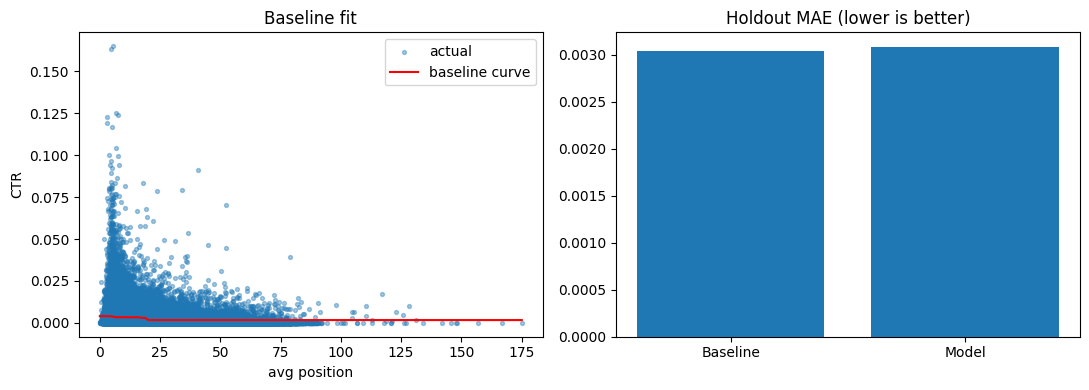

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(holdout_df['avg_position'], holdout_df['ctr'], s=8, alpha=0.4, label='actual')
order = holdout_df.sort_values('avg_position')
ax[0].plot(order['avg_position'], order['expected_ctr_baseline'], color='red', label='baseline curve')
ax[0].set_xlabel('avg position'); ax[0].set_ylabel('CTR'); ax[0].legend(); ax[0].set_title('Baseline fit')

ax[1].bar(['Baseline', 'Model'], [baseline_mae, model_mae])
ax[1].set_title('Holdout MAE (lower is better)')
plt.tight_layout()
plt.savefig('model_vs_baseline.png', dpi=150)
plt.show()


## 5. Opportunity scoring + reason codes

For every page in the holdout (and, once validated, the full dataset), compute an estimated **lost-click volume**: `(expected_ctr - actual_ctr) * impressions`. Rank descending. Assign a reason code + recommended action.


In [10]:
def score_and_rank(frame, expected_col='expected_ctr_model'):
    out = frame.copy()
    out['lost_clicks_est'] = (out[expected_col] - out['ctr']) * out['impressions']

    def reason_code(row):
        if row['lost_clicks_est'] <= 0:
            return 'On/above expected — protect', 'monitor'
        if row['impressions'] > out['impressions'].median() and row['avg_position'] <= 5:
            return 'High visibility, under-clicked — likely metadata issue', 'rewrite_metadata'
        if row['avg_position'] <= 10:
            return 'Ranking well, CTR lagging — content/snippet review', 'content_review'
        return 'Low visibility and under-clicked — lower priority', 'monitor'

    codes = out.apply(reason_code, axis=1, result_type='expand')
    out['reason_code'], out['recommended_action'] = codes[0], codes[1]
    return out.sort_values('lost_clicks_est', ascending=False)

ranked = score_and_rank(holdout_df)
ranked[['page', 'avg_position', 'impressions', 'ctr', 'expected_ctr_model',
        'lost_clicks_est', 'reason_code', 'recommended_action']].head(25)


,page,avg_position,impressions,ctr,expected_ctr_model,lost_clicks_est,reason_code,recommended_action
49846,content_2e6f70bef2a448dd,0.229229,123274.0,0.000633,0.050426,6138.201676,"High visibility, under-clicked — likely metada...",rewrite_metadata
23780,content_f352b7cfd0b2f434,3.787439,845725.0,0.001860,0.004665,2372.332961,"High visibility, under-clicked — likely metada...",rewrite_metadata
51636,content_21309e9a83c83653,4.919521,983861.0,0.001822,0.003911,2054.821638,"High visibility, under-clicked — likely metada...",rewrite_metadata
31991,content_fe3fd3422852d721,3.731406,898446.0,0.003331,0.005528,1973.761466,"High visibility, under-clicked — likely metada...",rewrite_metadata
58148,content_8d7d99f109e19aa2,2.486103,657937.0,0.002383,0.005199,1852.530408,"High visibility, under-clicked — likely metada...",rewrite_metadata
98583,content_62770e1299963fe4,4.816030,564098.0,0.001197,0.004119,1648.379470,"High visibility, under-clicked — likely metada...",rewrite_metadata
41439,content_e578ac84778da489,5.475185,530854.0,0.001194,0.003613,1284.189294,"Ranking well, CTR lagging — content/snippet re...",content_review
30804,content_40ffbbae932be2a0,6.447289,506344.0,0.000458,0.002775,1172.858624,"Ranking well, CTR lagging — content/snippet re...",content_review
93734,content_f43118e089ecc69a,6.151302,694417.0,0.001080,0.002734,1148.724715,"Ranking well, CTR lagging — content/snippet re...",content_review
39306,content_6a9c79f55413b447,3.607172,385469.0,0.003040,0.005580,978.869537,"High visibility, under-clicked — likely metada...",rewrite_metadata


## 6. Export results for the paper

Save the ranked action list and the model-vs-baseline comparison — these feed the **Results** and **Ranked recommendations** sections of the deployed paper. Remember the public-safe rule: no raw page URLs/domains if that would deanonymize a client — use hashed or generic page IDs when publishing the paper's tables/charts.


In [11]:
ranked.to_csv('ranked_opportunities_holdout.csv', index=False)
pd.DataFrame({
    'metric': ['MAE', 'R2'],
    'baseline': [baseline_mae, baseline_r2],
    'model': [model_mae, model_r2],
}).to_csv('model_vs_baseline_metrics.csv', index=False)
print('Saved: ranked_opportunities_holdout.csv, model_vs_baseline_metrics.csv, model_vs_baseline.png')


Saved: ranked_opportunities_holdout.csv, model_vs_baseline_metrics.csv, model_vs_baseline.png


In [12]:
import pandas as pd
metrics = pd.read_csv('model_vs_baseline_metrics.csv')
print(metrics.to_string(index=False))

metric  baseline    model
   MAE  0.003044 0.003086
    R2  0.033664 0.056620


In [13]:
from google.colab import files

files.download('model_vs_baseline.png')
files.download('ranked_opportunities_holdout.csv')
files.download('model_vs_baseline_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Next steps for you

- Swap the `CONFIG` placeholders for the real table/column names from Starter Notebook 03.
- Run this on the **full warehouse** once the holdout validation looks sane, and re-export the final ranked list.
- Drop this notebook into `work/` and fill `paper_draft.md` (in this same output) with your real numbers and charts.
- Anonymize/generalize `page` identifiers before anything goes into the public paper.
